## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [2]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [5]:
# TODO: drop the Customer ID column  
df = df.drop(columns=["Customer ID"])
df.head()

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [6]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Co

In [7]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [8]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [10]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male'].copy()
female_df = df[df['Gender'] == 'Female'].copy()
print("Số khách nam:", male_df.shape[0])
print("Số khách nữ:", female_df.shape[0])

Số khách nam: 2652
Số khách nữ: 1248


## **EDA**

### **Item Purchased**

In [11]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers

top_item_male = male_df['Item Purchased'].value_counts().reset_index()
top_item_female = female_df['Item Purchased'].value_counts().reset_index()
top_item_all = df['Item Purchased'].value_counts().reset_index()
print("----------Top Items for Male----------\n")
print(top_item_male)
print("----------Top Items for Female----------\n")
print(top_item_female)
print("----------Top Items for Male----------\n")
print(top_item_all)


----------Top Items for Male----------

   Item Purchased  count
0           Pants    123
1         Jewelry    119
2           Dress    114
3            Coat    114
4         Sweater    114
5           Scarf    112
6           Shirt    110
7          Shorts    109
8          Jacket    109
9           Skirt    109
10       Backpack    106
11           Belt    106
12     Sunglasses    105
13         Blouse    105
14         Gloves    103
15       Sneakers    103
16            Hat    102
17          Shoes    102
18          Socks    101
19        Sandals    101
20        T-shirt    101
21         Hoodie    100
22          Jeans     95
23        Handbag     95
24          Boots     94
----------Top Items for Female----------

   Item Purchased  count
0          Blouse     66
1           Shirt     59
2         Sandals     59
3         Handbag     58
4           Socks     58
5      Sunglasses     56
6            Belt     55
7          Jacket     54
8           Dress     52
9         Jewelry 

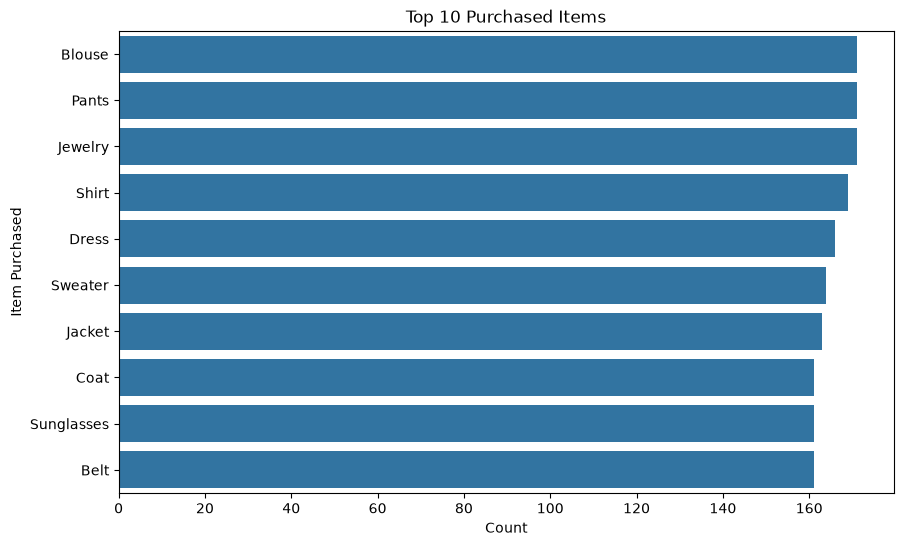

In [12]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
#     legend=?
# )
# plt.title?
# plt.xlabel?
# plt.ylabel?
# plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_all.head(10),
    x='count',
    y='Item Purchased',
    legend=False,
)
plt.title("Top 10 Purchased Items")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

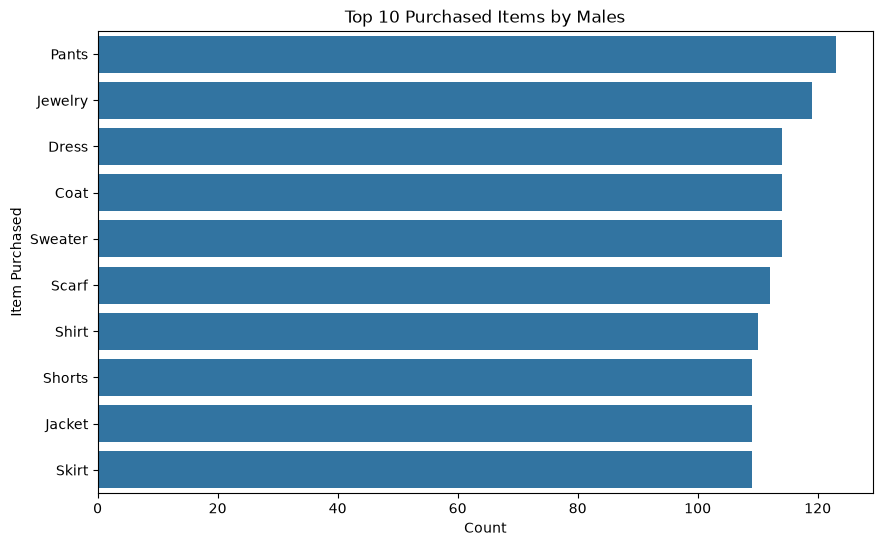

In [13]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
# )
# plt.title("Top 10 Purchased Items by Males")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_male.head(10),
    x='count',
    y='Item Purchased',
    legend=False,
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

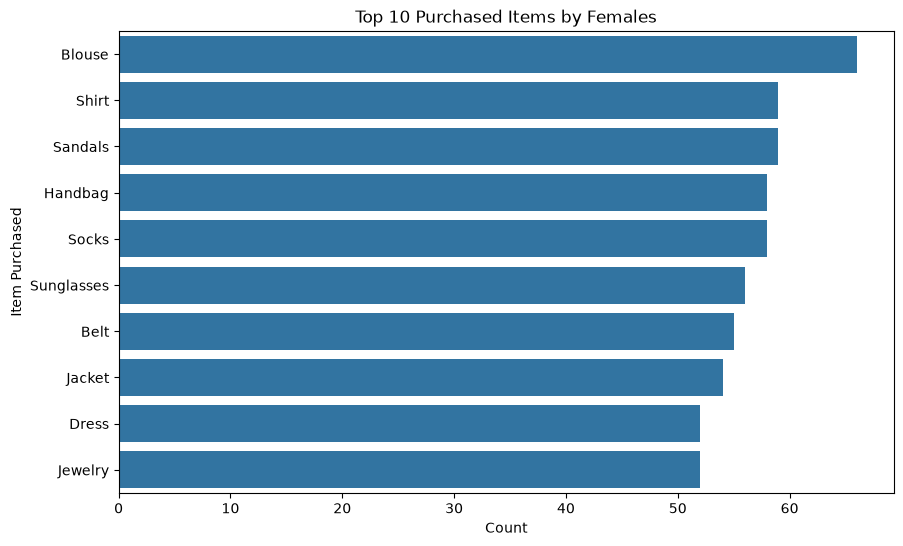

In [14]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_item_f.head(10),
#     y='Item Purchased',
#     x='count',
#     hue='Item Purchased',
#     dodge=False,
#     legend=False
# )
# plt.title("Top 10 Purchased Items by Females")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_female.head(10),
    y='Item Purchased',
    x='count',
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

In [15]:
# TODO: count Size with value_counts() for all customers
df['Size'].value_counts()

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [30]:
# TODO: count Size with value_counts() for male_df and female_df
print("Male size:", male_df['Size'].value_counts())
print("Female size:", female_df['Size'].value_counts())

Male size: Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
Female size: Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [31]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg = df['Category'].value_counts().reset_index()

In [32]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg_male = male_df['Category'].value_counts().reset_index()
ctg_female = female_df['Category'].value_counts().reset_index()

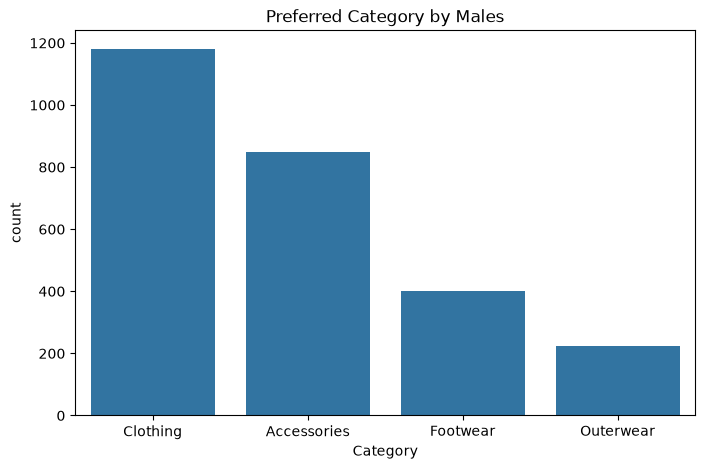

In [33]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     ?
# )
# plt.title("Preferred Category by Males")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_male,
    x='Category',
    y='count',
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

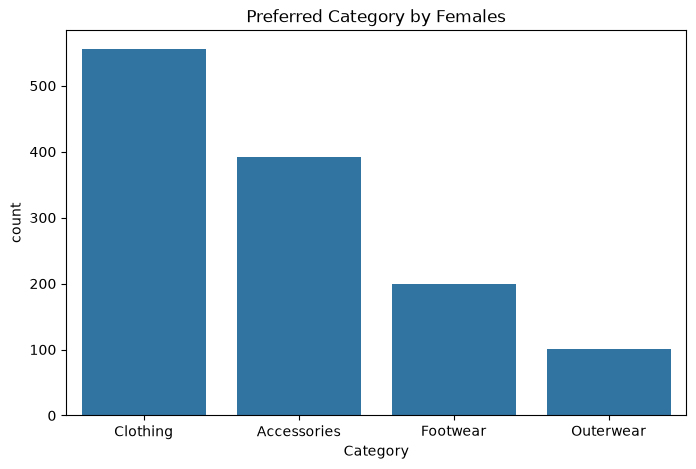

In [34]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()
plt.figure(figsize=(8, 5))
sns.barplot(
   data=ctg_female,
    x='Category',
    y='count',
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

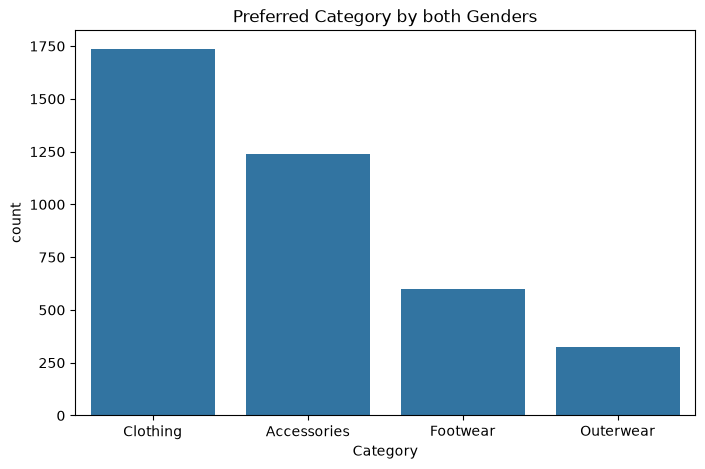

In [35]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     data=ctg,
#     x='Category',
#     y='count',
#     hue='Category',
#     dodge=False,
#     legend=False
# )
# plt.title("Preferred Category by both Genders")
# plt.show()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
)
plt.title("Preferred Category by both Genders")
plt.show()


In [36]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
# waffle_data_m = dict(male_df['Category'].value_counts())
# waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()
waffle_data_male= dict(male_df['Category'].value_counts())
waffle_data_female = dict(female_df['Category'].value_counts())

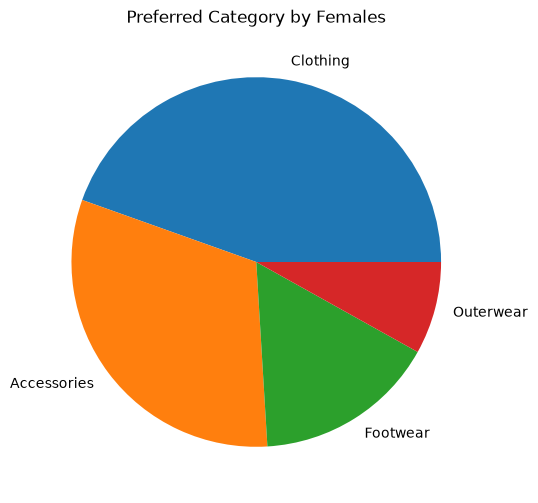

In [37]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.show()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_female.values(),
    labels=waffle_data_female.keys(),
)
plt.title("Preferred Category by Females")
plt.show()

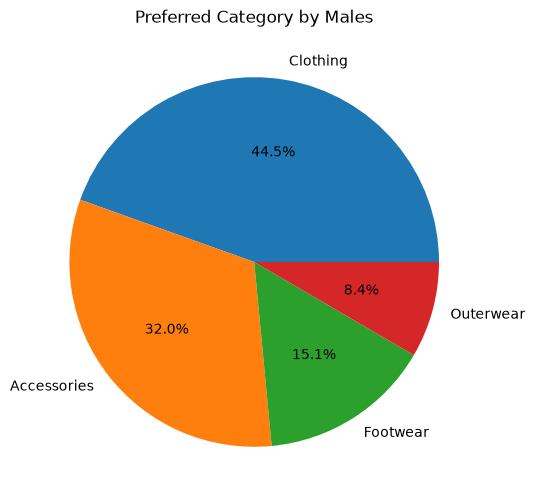

In [38]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#     waffle_data_m.values(),
#     labels=waffle_data_m.keys(),
#     autopct='%1.1f%%'
# )
# plt.title("Preferred Category by Males")
# plt.show() 
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_male.values(),
    labels=waffle_data_male.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [39]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f = ?
# avg_cr_f = ?
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()

In [40]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()

In [41]:
# avg_cr_m,avg_cr_f
print(avg_cr_m,avg_cr_f)

3.7319220999153258 3.7044964028776977


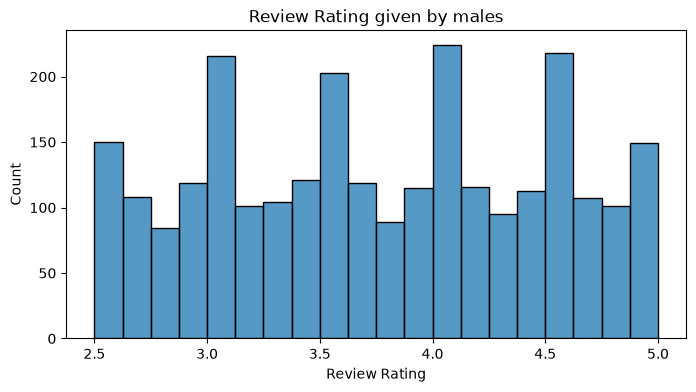

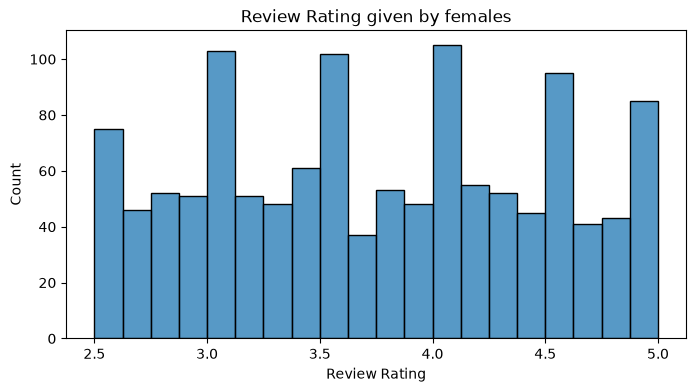

In [42]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [43]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.2    52
3.9    52
4.0    52
3.0    49
3.3    49
4.1    48
4.9    48
3.5    48
3.6    46
4.8    46
4.7    46
3.1    46
4.6    46
4.3    45
2.6    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [44]:
# TODO: sum Purchase Amount (USD) for males
# m_tpa = ?
m_tpa = male_df['Purchase Amount (USD)'].sum()
# # TODO: sum Purchase Amount (USD) for females
# f_tpa =?
f_tpa = female_df['Purchase Amount (USD)'].sum()

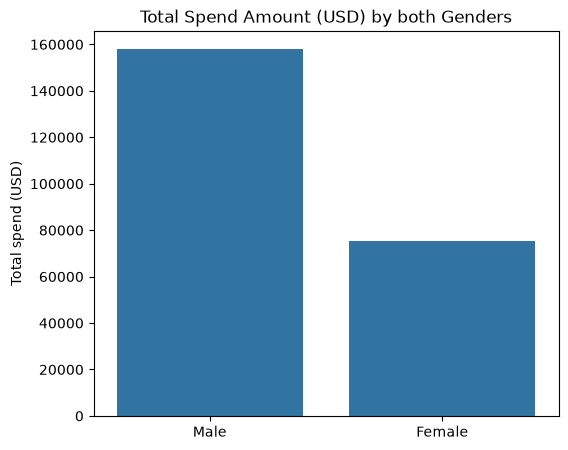

In [45]:
# TODO: plot total spend by gender with sns.barplot()
# plt.figure(figsize=(6, 5))
# sns.barplot(
#     ?
# )
# plt.title("Total Spend Amount (USD) by both Genders")
# plt.ylabel('Total spend (USD)')
# plt.show()
plt.figure(figsize=(6, 5))
sns.barplot(
    x=['Male', 'Female'],
    y=[m_tpa, f_tpa],
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [46]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_f = cr_f
# ca_f = female_df[female_df['Category']=='Accessories']
# cf_f = ?
# co_f = ?
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [47]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_m = cr_m
# ca_m = ?
# cf_m = ?
# co_m = ?
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [48]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

<Axes: >

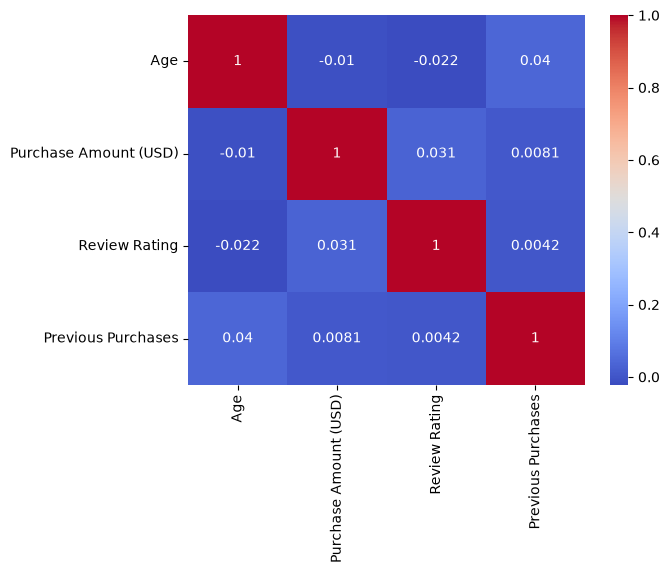

In [50]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', annot=True)

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [51]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
# df = pd.get_dummies(df, columns=[?], dtype=?)
# df.head()
df = pd.get_dummies(df, columns=['Gender', 'Size', 'Category'], dtype=int)
df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [52]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# df['Amount_minmax'] = ?
# df['Age_standard'] = ?
# df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()
from sklearn.preprocessing import MinMaxScaler, StandardScaler
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
df['Amount_minmax'] = min_max_scaler.fit_transform(df[['Purchase Amount (USD)']])
df['Age_standard'] = standard_scaler.fit_transform(df[['Age']])
df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [53]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
# df['Amount_bin'] = ?
# df['Amount_bin'].value_counts()
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)
df['Amount_bin'].value_counts()

Amount_bin
Low       1345
High      1297
Medium    1258
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Nhóm hàng quần áo(Clothing) và phụ kiện(Accessories) chiếm tỷ trọng lớn nhất ở cả hai giới tính; kích thước phổ biến nhất được mua là size M và L
- Khách hàng nam giới chiếm tổng số tiền chi tiêulớn hơn nữ giới
- Mức điểm đánh giá trung bình không có sự chênh lệch đáng kể giữa nam và nữ, phân bố đều ở các phân khúc sản phẩm
- Khoảng gần một nửa khách hàng(43%)  đã áp dụng mã khuyến mãi khi thanh toán, việc có mã giảm giá giúp kích thích giao dịch mua lại sản phẩm


Caveat: correlation is not causation.